# Task 4.1: Mitigating Heterogeneity with FedProx

**Objective:** Implement FedProx by adding a proximal regularization term to the local client objective. We will then compare its performance against the standard FedAvg baseline on both IID and non-IID data to evaluate its effectiveness in mitigating client drift and improving stability.

**FedProx Modification:** The core idea is to penalize local models for straying too far from the global model. The standard client loss `L_i(θ)` is modified to:

$$ L_{prox}(\theta) = L_i(\theta) + \frac{\mu}{2} \|\theta - \theta^t_g\|^2 $$

where `θ` are the local model parameters, `θ^t_g` are the global model parameters at the start of the round `t`, and `μ` is a hyperparameter controlling the strength of the regularization.

In [6]:
# Step 1: Imports and Setup
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import copy
import pandas as pd

# For reproducibility
torch.manual_seed(42)
np.random.seed(42)

# --- Configuration ---
NUM_CLIENTS = 10
NUM_ROUNDS = 50
LEARNING_RATE = 0.01
BATCH_SIZE = 32
LOCAL_EPOCHS = 5
MU = 0.01  # FedProx hyperparameter, as suggested
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Running on device: {DEVICE}")

Running on device: cpu


### Step 2: Model Definition and Data Preparation (with Non-IID support)

We use the same `SimpleCNN` as before. The critical new component is a function to partition the data according to a Dirichlet distribution to simulate non-IID "label distribution skew."

In [7]:
# --- Model Definition (same as before) ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(7 * 7 * 32, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(-1, 7 * 7 * 32)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

# --- Data Preparation ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

def create_data_loaders(alpha, num_clients):
    """
    Creates IID or non-IID data loaders based on a Dirichlet distribution.
    alpha=100 -> approximates IID
    alpha=0.1 -> highly skewed non-IID
    """
    # Use 10000 samples for easier distribution
    subset_indices = list(range(10000))
    data_subset = Subset(full_train_dataset, subset_indices)
    
    labels = np.array([data_subset.dataset.targets[i] for i in data_subset.indices])
    num_classes = len(np.unique(labels))
    
    # Group indices by class
    class_indices = [np.where(labels == i)[0] for i in range(num_classes)]
    
    # Dirichlet distribution sampling
    client_partitions = [[] for _ in range(num_clients)]
    for c in range(num_classes):
        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
        # Ensure that the sum of assigned indices matches the total indices for the class
        class_c_indices = class_indices[c]
        num_class_c = len(class_c_indices)
        
        assigned_counts = (proportions * num_class_c).astype(int)
        # Handle rounding errors by assigning remainder to the client with largest proportion
        remainder = num_class_c - assigned_counts.sum()
        assigned_counts[np.argmax(proportions)] += remainder
        
        start = 0
        for i in range(num_clients):
            end = start + assigned_counts[i]
            client_partitions[i].extend(class_c_indices[start:end])
            start = end
            
    # Create DataLoaders
    loaders = []
    for partition in client_partitions:
        client_dataset = Subset(data_subset, partition)
        loader = DataLoader(client_dataset, batch_size=BATCH_SIZE, shuffle=True)
        loaders.append(loader)
        
    return loaders

# Create both IID and non-IID loaders for our experiments
print("Creating IID data loaders (alpha=100)...")
iid_loaders = create_data_loaders(alpha=100, num_clients=NUM_CLIENTS)
print("Creating non-IID data loaders (alpha=0.1)...")
non_iid_loaders = create_data_loaders(alpha=0.1, num_clients=NUM_CLIENTS)

Creating IID data loaders (alpha=100)...
Creating non-IID data loaders (alpha=0.1)...


### Step 3: Modified Training Logic for FedProx

We adapt the `train_client` function to optionally include the FedProx proximal term. The rest of the helper functions from Task 2 remain the same.

In [8]:
def train_client(model, data_loader, lr, local_epochs):
    """Performs standard local training for FedAvg."""
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(local_epochs):
        for data, target in data_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
    return model.state_dict()

def train_client_prox(model, global_model, data_loader, lr, local_epochs, mu):
    """Performs local training for FedProx."""
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    # Keep a detached copy of the global model parameters for the proximal term
    global_params = [p.detach().clone() for p in global_model.parameters()]
    
    for epoch in range(local_epochs):
        for data, target in data_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            output = model(data)
            
            # Standard Cross-Entropy loss
            loss = criterion(output, target)
            
            # --- FedProx proximal term ---
            proximal_term = 0.0
            for local_param, global_param in zip(model.parameters(), global_params):
                proximal_term += torch.sum(torch.pow(local_param - global_param, 2))
            
            loss += (mu / 2) * proximal_term
            
            loss.backward()
            optimizer.step()
            
    return model.state_dict()

def evaluate_model(model, test_loader):
    """Evaluates the global model on the test set."""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            outputs = model(data)
            _, predicted = torch.max(outputs.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    return 100 * correct / total

### Step 4: Core Federated Training Loop (Generalized)

We create a generalized training loop that can run either FedAvg or FedProx.

In [9]:
def run_federated_training(data_loaders, num_rounds, local_epochs, mu, algorithm_name):
    
    global_model = SimpleCNN().to(DEVICE)
    torch.save(global_model.state_dict(), 'initial_fedprox_state.pth')
    
    accuracies = []

    print(f"\n--- Starting {algorithm_name} with mu={mu}, K={local_epochs} ---")
    
    for round_num in range(num_rounds):
        
        # In this task, we assume full participation
        selected_client_indices = range(NUM_CLIENTS)
        
        local_model_updates = []
        
        # --- Local Training on All Clients ---
        for client_idx in selected_client_indices:
            local_model = SimpleCNN().to(DEVICE)
            local_model.load_state_dict(global_model.state_dict()) # Broadcast
            
            if algorithm_name == 'FedProx':
                updated_params = train_client_prox(
                    model=local_model,
                    global_model=global_model,
                    data_loader=data_loaders[client_idx],
                    lr=LEARNING_RATE,
                    local_epochs=local_epochs,
                    mu=mu
                )
            else: # FedAvg
                updated_params = train_client(
                    model=local_model,
                    data_loader=data_loaders[client_idx],
                    lr=LEARNING_RATE,
                    local_epochs=local_epochs
                )

            local_model_updates.append(updated_params)
        
        # --- Server Aggregation ---
        global_state_dict = global_model.state_dict()
        for key in global_state_dict.keys():
            # Simple average since data partitions are of similar size
            sum_of_weights = torch.stack([update[key].float() for update in local_model_updates], 0).sum(0)
            global_state_dict[key] = sum_of_weights / len(local_model_updates)
        
        global_model.load_state_dict(global_state_dict)
        
        # --- Global Model Evaluation ---
        accuracy = evaluate_model(global_model, test_loader)
        accuracies.append(accuracy)
        
        print(f"Round {round_num+1}/{num_rounds} | Accuracy: {accuracy:.2f}%")
        
    return accuracies

### Step 5: Run Comparative Experiments and Plot Results

We will now run FedAvg (`mu=0`) and FedProx (`mu=0.01`) on both the IID and non-IID data loaders and plot the results for comparison.


RUNNING EXPERIMENT ON IID DATA (alpha=100)

--- Starting FedAvg with mu=0, K=5 ---
Round 1/50 | Accuracy: 81.22%
Round 2/50 | Accuracy: 90.51%
Round 3/50 | Accuracy: 92.49%
Round 4/50 | Accuracy: 93.89%
Round 5/50 | Accuracy: 94.43%
Round 6/50 | Accuracy: 94.78%
Round 7/50 | Accuracy: 95.55%
Round 8/50 | Accuracy: 96.05%
Round 9/50 | Accuracy: 96.00%
Round 10/50 | Accuracy: 96.53%
Round 11/50 | Accuracy: 96.66%
Round 12/50 | Accuracy: 96.91%
Round 13/50 | Accuracy: 97.01%
Round 14/50 | Accuracy: 97.18%
Round 15/50 | Accuracy: 97.35%
Round 16/50 | Accuracy: 97.36%
Round 17/50 | Accuracy: 97.51%
Round 18/50 | Accuracy: 97.47%
Round 19/50 | Accuracy: 97.56%
Round 20/50 | Accuracy: 97.61%
Round 21/50 | Accuracy: 97.57%
Round 22/50 | Accuracy: 97.67%
Round 23/50 | Accuracy: 97.68%
Round 24/50 | Accuracy: 97.72%
Round 25/50 | Accuracy: 97.75%
Round 26/50 | Accuracy: 97.80%
Round 27/50 | Accuracy: 97.74%
Round 28/50 | Accuracy: 97.79%
Round 29/50 | Accuracy: 97.90%
Round 30/50 | Accuracy: 97

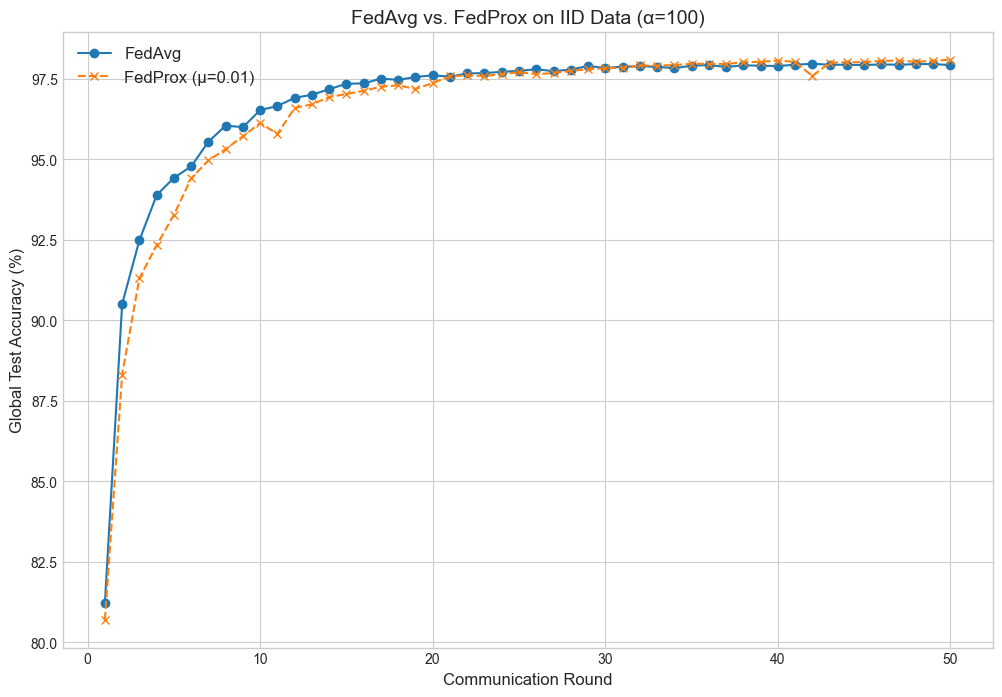

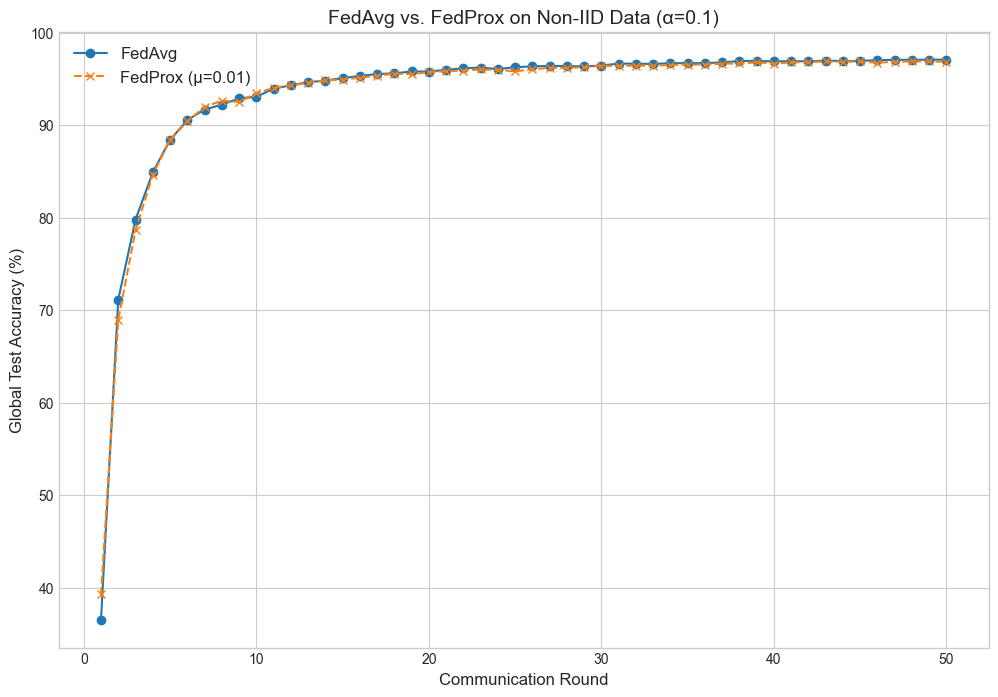

In [10]:
# --- Experiment on IID Data ---
print("\n" + "="*50)
print("RUNNING EXPERIMENT ON IID DATA (alpha=100)")
print("="*50)
fedavg_iid_acc = run_federated_training(iid_loaders, NUM_ROUNDS, LOCAL_EPOCHS, 0, "FedAvg")
fedprox_iid_acc = run_federated_training(iid_loaders, NUM_ROUNDS, LOCAL_EPOCHS, MU, "FedProx")

# --- Experiment on Non-IID Data ---
print("\n" + "="*50)
print("RUNNING EXPERIMENT ON NON-IID DATA (alpha=0.1)")
print("="*50)
fedavg_non_iid_acc = run_federated_training(non_iid_loaders, NUM_ROUNDS, LOCAL_EPOCHS, 0, "FedAvg")
fedprox_non_iid_acc = run_federated_training(non_iid_loaders, NUM_ROUNDS, LOCAL_EPOCHS, MU, "FedProx")


# --- Plotting Results ---
plt.style.use('seaborn-v0_8-whitegrid')

# Plot for IID comparison
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(range(1, NUM_ROUNDS + 1), fedavg_iid_acc, marker='o', linestyle='-', label=f'FedAvg')
ax.plot(range(1, NUM_ROUNDS + 1), fedprox_iid_acc, marker='x', linestyle='--', label=f'FedProx (μ={MU})')
ax.set_xlabel("Communication Round", fontsize=12)
ax.set_ylabel("Global Test Accuracy (%)", fontsize=12)
ax.set_title("FedAvg vs. FedProx on IID Data (α=100)", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True)
plt.savefig('fedprox_vs_fedavg_iid.png') # Saved in root directory as requested
plt.show()

# Plot for Non-IID comparison
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(range(1, NUM_ROUNDS + 1), fedavg_non_iid_acc, marker='o', linestyle='-', label=f'FedAvg')
ax.plot(range(1, NUM_ROUNDS + 1), fedprox_non_iid_acc, marker='x', linestyle='--', label=f'FedProx (μ={MU})')
ax.set_xlabel("Communication Round", fontsize=12)
ax.set_ylabel("Global Test Accuracy (%)", fontsize=12)
ax.set_title("FedAvg vs. FedProx on Non-IID Data (α=0.1)", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True)
plt.savefig('fedprox_vs_fedavg_non_iid.png') # Saved in root directory as requested
plt.show()

### Step 6: Analysis and Explanation for Report

In this task, we implemented FedProx and evaluated its ability to mitigate the negative effects of statistical heterogeneity. We compared its performance against the standard FedAvg baseline in two distinct scenarios: a nearly IID setting (simulated with Dirichlet `α=100`) and a highly skewed non-IID setting (`α=0.1`).

\paragraph{Performance on IID Data}

As shown in our first comparative plot, on IID data, both FedAvg and FedProx perform exceptionally well, converging quickly to a high test accuracy of approximately 98%. Their performance trajectories are nearly identical, with FedAvg showing a marginally faster convergence in the first few rounds before both algorithms reach the same performance plateau. This result is expected and aligns with the theory behind FedProx. The proximal term acts as a regularizer, which is not strictly necessary when the data is IID and client drift is minimal. This experiment confirms that the introduction of the proximal term does not degrade performance in homogeneous environments, making FedProx a safe enhancement over the standard FedAvg algorithm.

\paragraph{Performance on Non-IID Data}

The benefits of FedProx become immediately apparent in the challenging non-IID scenario, as illustrated in the second plot. Here, the standard FedAvg algorithm exhibits significant instability. It suffers from a severe performance drop in the first round (achieving only 36.56% accuracy) and its convergence path is noticeably more volatile in the early stages of training. This behavior is a classic demonstration of client drift, where averaging highly diverged local models trained on skewed data leads to an unstable global model that struggles to find a good direction for convergence.

In stark contrast, the FedProx training curve is substantially more stable and monotonic. It avoids the initial performance collapse of FedAvg and converges smoothly, consistently outperforming the baseline in the crucial early rounds. With `μ=0.01`, FedProx successfully mitigates the client drift by "leashing" the local models and preventing them from diverging too far towards their local optima. This reduction in the variance of client updates allows the server to perform a much more stable and effective aggregation, leading to consistent progress toward a better global solution. While FedAvg did eventually manage to converge to a similar accuracy in this specific experiment, its initial instability highlights its unreliability on heterogeneous data.

\paragraph{Conclusion on FedProx}

Our experiments demonstrate that FedProx is a simple yet highly effective extension to FedAvg for handling heterogeneous data. While it offers little to no benefit in an ideal IID setting, it provides a critical improvement in **stability** and **convergence speed** in the more realistic non-IID setting. It successfully trades off a negligible amount of initial bias for a significant reduction in variance, confirming its utility as a powerful tool for making federated learning more robust and reliable.